In [1]:
import pandas as pd
import pickle
import numpy as np

In [70]:
df = pickle.load(open('dataset_level2.pkl','rb'))

In [71]:
df

# batting_team
# bowling team
# city
# current score
# ball left
# wickets left
# current rr
# last five

,match_id,batting_team,bowling_team,ball,runs,player_dismissed,city,venue
0,2,Australia,Sri Lanka,0.1,0,0,NaN,Melbourne Cricket Ground
1,2,Australia,Sri Lanka,0.2,0,0,NaN,Melbourne Cricket Ground
2,2,Australia,Sri Lanka,0.3,1,0,NaN,Melbourne Cricket Ground
3,2,Australia,Sri Lanka,0.4,2,0,NaN,Melbourne Cricket Ground
4,2,Australia,Sri Lanka,0.5,0,0,NaN,Melbourne Cricket Ground
...,...,...,...,...,...,...,...,...
365431,3039,Sri Lanka,Australia,19.3,1,0,Colombo,R Premadasa Stadium
365432,3039,Sri Lanka,Australia,19.4,0,0,Colombo,R Premadasa Stadium
365433,3039,Sri Lanka,Australia,19.5,0,DM de Silva,Colombo,R Premadasa Stadium
365434,3039,Sri Lanka,Australia,19.6,2,0,Colombo,R Premadasa Stadium


In [72]:
df.isnull().sum()

match_id               0
batting_team           0
bowling_team           0
ball                   0
runs                   0
player_dismissed       0
city                8549
venue                  0
dtype: int64

In [73]:
df[df['city'].isnull()]['venue'].value_counts()

venue
Dubai International Cricket Stadium        3092
Pallekele International Cricket Stadium    2066
Melbourne Cricket Ground                   1453
Sydney Cricket Ground                       749
Adelaide Oval                               498
Harare Sports Club                          372
Sylhet International Cricket Stadium        128
Sharjah Cricket Stadium                     127
Carrara Oval                                 64
Name: count, dtype: int64

In [74]:
cities = np.where(df['city'].isnull(),df['venue'].str.split().apply(lambda x:x[0]),df['city'])

In [75]:
df['city'] = cities

In [83]:
df.isnull().sum()

match_id            0
batting_team        0
bowling_team        0
ball                0
runs                0
player_dismissed    0
city                0
dtype: int64

In [85]:
df.drop(columns=['venue'],inplace=True)

KeyError: "['venue'] not found in axis"

In [86]:
df['city'].value_counts()[df['city'].value_counts() > 600].sum()

92790

In [87]:
eligible_cities = df['city'].value_counts()[df['city'].value_counts() > 600].index.tolist()

In [88]:
df = df[df['city'].isin(eligible_cities)]

In [89]:
df.dtypes

match_id              int64
batting_team         object
bowling_team         object
ball                float64
runs                  int64
player_dismissed     object
city                 object
dtype: object

In [92]:
df['runs'] = pd.to_numeric(df['runs'])
df['current_score'] = df.groupby('match_id')['runs'].cumsum()

In [93]:
df['player_dismissed'].apply(type).value_counts()

player_dismissed
<class 'str'>    92790
Name: count, dtype: int64

In [94]:
df['over'] = df['ball'].apply(lambda x:str(x).split(".")[0])
df['ball_no'] = df['ball'].apply(lambda x:str(x).split(".")[1])
df

,match_id,batting_team,bowling_team,ball,runs,player_dismissed,city,current_score,over,ball_no
0,2,Australia,Sri Lanka,0.1,0,0,Melbourne,0,0,1
1,2,Australia,Sri Lanka,0.2,0,0,Melbourne,0,0,2
2,2,Australia,Sri Lanka,0.3,1,0,Melbourne,1,0,3
3,2,Australia,Sri Lanka,0.4,2,0,Melbourne,3,0,4
4,2,Australia,Sri Lanka,0.5,0,0,Melbourne,3,0,5
...,...,...,...,...,...,...,...,...,...,...
365431,3039,Sri Lanka,Australia,19.3,1,0,Colombo,125,19,3
365432,3039,Sri Lanka,Australia,19.4,0,0,Colombo,125,19,4
365433,3039,Sri Lanka,Australia,19.5,0,DM de Silva,Colombo,125,19,5
365434,3039,Sri Lanka,Australia,19.6,2,0,Colombo,127,19,6


In [95]:
df['balls_bowled'] = (df['over'].astype('int')*6) + df['ball_no'].astype('int')
df

,match_id,batting_team,bowling_team,ball,runs,player_dismissed,city,current_score,over,ball_no,balls_bowled
0,2,Australia,Sri Lanka,0.1,0,0,Melbourne,0,0,1,1
1,2,Australia,Sri Lanka,0.2,0,0,Melbourne,0,0,2,2
2,2,Australia,Sri Lanka,0.3,1,0,Melbourne,1,0,3,3
3,2,Australia,Sri Lanka,0.4,2,0,Melbourne,3,0,4,4
4,2,Australia,Sri Lanka,0.5,0,0,Melbourne,3,0,5,5
...,...,...,...,...,...,...,...,...,...,...,...
365431,3039,Sri Lanka,Australia,19.3,1,0,Colombo,125,19,3,117
365432,3039,Sri Lanka,Australia,19.4,0,0,Colombo,125,19,4,118
365433,3039,Sri Lanka,Australia,19.5,0,DM de Silva,Colombo,125,19,5,119
365434,3039,Sri Lanka,Australia,19.6,2,0,Colombo,127,19,6,120


In [96]:
df['balls_left'] = 120 - df['balls_bowled']
df['balls_left'] = df['balls_left'].apply(lambda x:0 if x<0 else x)
df

,match_id,batting_team,bowling_team,ball,runs,player_dismissed,city,current_score,over,ball_no,balls_bowled,balls_left
0,2,Australia,Sri Lanka,0.1,0,0,Melbourne,0,0,1,1,119
1,2,Australia,Sri Lanka,0.2,0,0,Melbourne,0,0,2,2,118
2,2,Australia,Sri Lanka,0.3,1,0,Melbourne,1,0,3,3,117
3,2,Australia,Sri Lanka,0.4,2,0,Melbourne,3,0,4,4,116
4,2,Australia,Sri Lanka,0.5,0,0,Melbourne,3,0,5,5,115
...,...,...,...,...,...,...,...,...,...,...,...,...
365431,3039,Sri Lanka,Australia,19.3,1,0,Colombo,125,19,3,117,3
365432,3039,Sri Lanka,Australia,19.4,0,0,Colombo,125,19,4,118,2
365433,3039,Sri Lanka,Australia,19.5,0,DM de Silva,Colombo,125,19,5,119,1
365434,3039,Sri Lanka,Australia,19.6,2,0,Colombo,127,19,6,120,0


In [97]:
# 1️⃣ wicket indicator from original string column
df['is_wicket'] = (df['player_dismissed'] != '0').astype(int)

# 2️⃣ cumulative wickets in match
df['wickets_fallen'] = df.groupby('match_id')['is_wicket'].cumsum()

# 3️⃣ wickets remaining
df['wickets_left'] = 10 - df['wickets_fallen']

In [69]:
df.dtypes

match_id              int64
batting_team         object
bowling_team         object
ball                float64
runs                  int64
player_dismissed      int32
city                 object
current_score         int64
over                 object
ball_no              object
balls_bowled          int32
balls_left            int64
wickets_left          int32
crr                 float64
last_five           float64
last30_rpb          float64
dtype: object

In [102]:
df['crr'] = (df['current_score']*6)/df['balls_bowled']

In [101]:
df.iloc[40:100]

,match_id,batting_team,bowling_team,ball,runs,player_dismissed,city,current_score,over,ball_no,balls_bowled,balls_left,is_wicket,wickets_fallen,wickets_left,crr
40,2,Australia,Sri Lanka,6.4,1,0,Melbourne,50,6,4,40,80,0,0,10,7.500000
41,2,Australia,Sri Lanka,6.5,1,0,Melbourne,51,6,5,41,79,0,0,10,7.463415
42,2,Australia,Sri Lanka,6.6,2,0,Melbourne,53,6,6,42,78,0,0,10,7.571429
43,2,Australia,Sri Lanka,7.1,0,0,Melbourne,53,7,1,43,77,0,0,10,7.395349
44,2,Australia,Sri Lanka,7.2,1,0,Melbourne,54,7,2,44,76,0,0,10,7.363636
45,2,Australia,Sri Lanka,7.3,1,0,Melbourne,55,7,3,45,75,0,0,10,7.333333
46,2,Australia,Sri Lanka,7.4,1,0,Melbourne,56,7,4,46,74,0,0,10,7.304348
47,2,Australia,Sri Lanka,7.5,4,0,Melbourne,60,7,5,47,73,0,0,10,7.659574
48,2,Australia,Sri Lanka,7.6,1,0,Melbourne,61,7,6,48,72,0,0,10,7.625000
49,2,Australia,Sri Lanka,8.1,1,0,Melbourne,62,8,1,49,71,0,0,10,7.591837


In [103]:
groups = df.groupby('match_id')

match_ids = df['match_id'].unique()
last_five = []

for id in match_ids:
    last_five.extend(
        groups.get_group(id)['runs']
        .rolling(window=30, min_periods=1)
        .sum()
        .values
        .tolist()
    )

In [104]:
df['last_five']=last_five


In [105]:
g = df.groupby('match_id')['runs']

df['last30_rpb'] = (
    g.rolling(30, min_periods=1).sum()
    / g.rolling(30, min_periods=1).count()
).reset_index(level=0, drop=True)

In [120]:
df.iloc[114:123]

,match_id,batting_team,bowling_team,ball,runs,player_dismissed,city,current_score,over,ball_no,balls_bowled,balls_left,is_wicket,wickets_fallen,wickets_left,crr,last_five,last30_rpb
114,2,Australia,Sri Lanka,18.3,2,0,Melbourne,153,18,3,111,9,0,3,7,8.270270,54.0,1.800000
115,2,Australia,Sri Lanka,18.4,0,TM Head,Melbourne,153,18,4,112,8,1,4,6,8.196429,53.0,1.766667
116,2,Australia,Sri Lanka,18.5,0,AJ Turner,Melbourne,153,18,5,113,7,1,5,5,8.123894,52.0,1.733333
117,2,Australia,Sri Lanka,18.6,1,0,Melbourne,154,18,6,114,6,0,5,5,8.105263,50.0,1.666667
118,2,Australia,Sri Lanka,19.1,4,0,Melbourne,158,19,1,115,5,0,5,5,8.243478,53.0,1.766667
119,2,Australia,Sri Lanka,19.2,0,0,Melbourne,158,19,2,116,4,0,5,5,8.172414,47.0,1.566667
120,2,Australia,Sri Lanka,19.3,2,0,Melbourne,160,19,3,117,3,0,5,5,8.205128,46.0,1.533333
121,2,Australia,Sri Lanka,19.4,1,0,Melbourne,161,19,4,118,2,0,5,5,8.186441,45.0,1.500000
122,2,Australia,Sri Lanka,19.5,1,TD Paine,Melbourne,162,19,5,119,1,1,6,4,8.168067,46.0,1.533333


In [108]:
groups = df.groupby('match_id')

match_ids = df['match_id'].unique()
last_five = []

for id in match_ids:
    match_df = groups.get_group(id)

    runs_last_5 = match_df['runs'].rolling(window=30, min_periods=1).sum()

    last_five.extend(runs_last_5.values.tolist())

In [109]:
df['last_five'] = last_five

In [110]:
df.groupby('match_id').sum()['runs']

match_id
2       168
4       187
9       141
10      195
11      194
       ... 
3033    129
3035    150
3036    120
3038    263
3039    128
Name: runs, Length: 768, dtype: int64

In [28]:
#df[['batting_team','bowling_team','city','current_score','balls_left','wickets_left','crr','last_five','']]

In [111]:
final_df = df.groupby('match_id').sum()['runs'].reset_index().merge(df,on='match_id')

In [113]:
final_df

,match_id,runs_x,batting_team,bowling_team,ball,runs_y,player_dismissed,city,current_score,over,ball_no,balls_bowled,balls_left,is_wicket,wickets_fallen,wickets_left,crr,last_five,last30_rpb
0,2,168,Australia,Sri Lanka,0.1,0,0,Melbourne,0,0,1,1,119,0,0,10,0.000000,0.0,0.000000
1,2,168,Australia,Sri Lanka,0.2,0,0,Melbourne,0,0,2,2,118,0,0,10,0.000000,0.0,0.000000
2,2,168,Australia,Sri Lanka,0.3,1,0,Melbourne,1,0,3,3,117,0,0,10,2.000000,1.0,0.333333
3,2,168,Australia,Sri Lanka,0.4,2,0,Melbourne,3,0,4,4,116,0,0,10,4.500000,3.0,0.750000
4,2,168,Australia,Sri Lanka,0.5,0,0,Melbourne,3,0,5,5,115,0,0,10,3.600000,3.0,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92785,3039,128,Sri Lanka,Australia,19.3,1,0,Colombo,125,19,3,117,3,0,8,2,6.410256,32.0,1.066667
92786,3039,128,Sri Lanka,Australia,19.4,0,0,Colombo,125,19,4,118,2,0,8,2,6.355932,32.0,1.066667
92787,3039,128,Sri Lanka,Australia,19.5,0,DM de Silva,Colombo,125,19,5,119,1,1,9,1,6.302521,32.0,1.066667
92788,3039,128,Sri Lanka,Australia,19.6,2,0,Colombo,127,19,6,120,0,0,9,1,6.350000,33.0,1.100000


In [123]:
final_df=final_df[['batting_team','bowling_team','city','current_score','balls_left','wickets_left','crr','last30_rpb','runs_x']]

In [124]:
final_df

,batting_team,bowling_team,city,current_score,balls_left,wickets_left,crr,last30_rpb,runs_x
0,Australia,Sri Lanka,Melbourne,0,119,10,0.000000,0.000000,168
1,Australia,Sri Lanka,Melbourne,0,118,10,0.000000,0.000000,168
2,Australia,Sri Lanka,Melbourne,1,117,10,2.000000,0.333333,168
3,Australia,Sri Lanka,Melbourne,3,116,10,4.500000,0.750000,168
4,Australia,Sri Lanka,Melbourne,3,115,10,3.600000,0.600000,168
...,...,...,...,...,...,...,...,...,...
92785,Sri Lanka,Australia,Colombo,125,3,2,6.410256,1.066667,128
92786,Sri Lanka,Australia,Colombo,125,2,2,6.355932,1.066667,128
92787,Sri Lanka,Australia,Colombo,125,1,1,6.302521,1.066667,128
92788,Sri Lanka,Australia,Colombo,127,0,1,6.350000,1.100000,128


In [127]:
final_df = final_df.dropna()

In [168]:
# unique batting teams
batting_teams = sorted(final_df["batting_team"].dropna().unique())

# unique bowling teams
bowling_teams = sorted(final_df["bowling_team"].dropna().unique())

# unique cities
cities = sorted(final_df["city"].dropna().unique())

batting_teams, bowling_teams, cities

(['Australia',
  'Bangladesh',
  'England',
  'India',
  'New Zealand',
  'Pakistan',
  'South Africa',
  'Sri Lanka',
  'West Indies'],
 ['Australia',
  'Bangladesh',
  'England',
  'India',
  'New Zealand',
  'Pakistan',
  'South Africa',
  'Sri Lanka',
  'West Indies'],
 ['Abu Dhabi',
  'Adelaide',
  'Ahmedabad',
  'Auckland',
  'Bangalore',
  'Barbados',
  'Basseterre',
  'Birmingham',
  'Bridgetown',
  'Brisbane',
  'Bristol',
  'Canberra',
  'Cape Town',
  'Cardiff',
  'Centurion',
  'Chandigarh',
  'Chattogram',
  'Chittagong',
  'Christchurch',
  'Colombo',
  'Dambulla',
  'Delhi',
  'Dhaka',
  'Dubai',
  'Durban',
  'Gros Islet',
  'Hamilton',
  'Harare',
  'Hobart',
  'Johannesburg',
  'Kandy',
  'Karachi',
  'Kingston',
  'Kolkata',
  'Lahore',
  'Lauderhill',
  'London',
  'Manchester',
  'Melbourne',
  'Mirpur',
  'Mount Maunganui',
  'Mumbai',
  'Nagpur',
  'Napier',
  'Nottingham',
  'Pallekele',
  'Perth',
  'Providence',
  'Pune',
  'Rajkot',
  'Rawalpindi',
  'Sharjah

In [132]:
final_df = final_df.sample(final_df.shape[0])

In [138]:
final_df.sample(2)

,batting_team,bowling_team,city,current_score,balls_left,wickets_left,crr,last30_rpb,runs_x
72888,England,Pakistan,Abu Dhabi,44,81,8,6.769231,1.2,129
22255,West Indies,Australia,Gros Islet,190,0,6,9.500000,2.0,196


In [139]:
X = final_df.drop(columns=['runs_x'])
y = final_df['runs_x']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [147]:
X_train

,batting_team,bowling_team,city,current_score,balls_left,wickets_left,crr,last30_rpb
47840,England,West Indies,Southampton,167,37,8,12.072289,1.533333
74698,Pakistan,India,Colombo,122,6,2,6.421053,0.833333
61654,Australia,Sri Lanka,Nottingham,13,105,9,5.200000,0.866667
29816,West Indies,Pakistan,Karachi,175,21,8,10.606061,1.666667
85532,South Africa,Australia,Melbourne,31,86,8,5.470588,1.000000
...,...,...,...,...,...,...,...,...
78712,West Indies,Bangladesh,Mirpur,135,26,6,8.617021,1.600000
67572,Australia,England,Barbados,147,0,4,7.350000,1.766667
7625,Australia,Pakistan,Harare,11,112,10,8.250000,1.375000
38592,England,Bangladesh,Dhaka,100,18,3,5.882353,0.766667


In [145]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error

In [149]:
trf = ColumnTransformer([
    ('trf', OneHotEncoder(sparse_output=False, drop='first'),
     ['batting_team','bowling_team','city'])
],
remainder='passthrough')

In [151]:
pipe = Pipeline(steps=[
    ('step1',trf),
    ('step2',StandardScaler()),
    ('step3',XGBRegressor(n_estimators=1000,learning_rate=0.2,max_depth=12,random_state=1))
])

In [166]:
feature_names = pipe.named_steps['step1'].get_feature_names_out()
import pandas as pd

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df

,feature,importance
26,trf__city_Canberra,0.051041
52,trf__city_Manchester,0.048415
24,trf__city_Brisbane,0.046207
25,trf__city_Bristol,0.031091
57,trf__city_Nagpur,0.029416
...,...,...
4,trf__batting_team_Pakistan,0.001510
45,trf__city_Kandy,0.001251
75,remainder__current_score,0.000786
79,remainder__last30_rpb,0.000384


In [153]:
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.949592113494873
3.081742729075909


In [156]:
pickle.dump(pipe,open('pipe.pkl','wb'))

In [157]:
import xgboost
xgboost.__version__

'2.1.0'

In [158]:
y_pred = pipe.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

results_df = X_test.copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred
results_df['Error'] = abs(results_df['Actual'] - results_df['Predicted'])

results_df.head()

R2 Score: 0.949592113494873
MAE: 3.081742729075909


,batting_team,bowling_team,city,current_score,balls_left,wickets_left,crr,last30_rpb,Actual,Predicted,Error
17622,Australia,New Zealand,Wellington,18,110,10,10.800000,1.800000,156,156.871460,0.871460
86744,Sri Lanka,Pakistan,Colombo,18,108,10,9.000000,1.500000,172,167.803528,4.196472
4120,Pakistan,New Zealand,Mount Maunganui,98,44,8,7.736842,1.366667,181,180.920761,0.079239
38721,Bangladesh,England,Dhaka,140,17,8,8.155340,1.366667,158,159.207352,1.207352
79331,Australia,England,Hobart,158,27,7,10.193548,1.566667,213,212.902344,0.097656


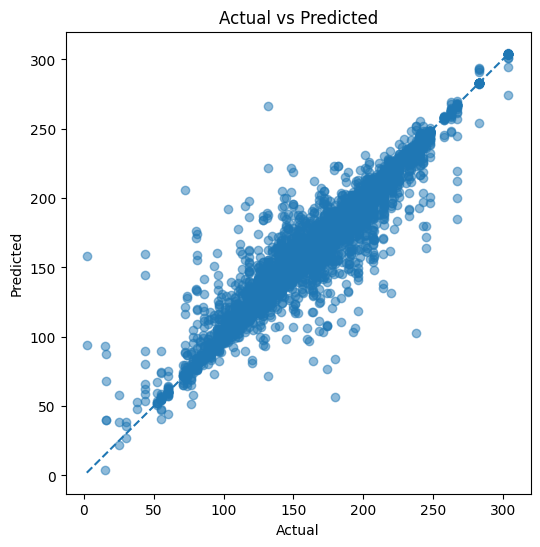

In [159]:
import matplotlib.pyplot as plt

# Predict
y_pred = pipe.predict(X_test)

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [167]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import time
import pandas as pd

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
        verbose=1  # progress
    ),
    
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        verbose=1  # progress
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=1000,
        learning_rate=0.2,
        max_depth=12,
        random_state=1,
        verbosity=1  # progress
    )
}

results = []

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    
    pipe = Pipeline([
        ('prep', trf),
        ('model', model)
    ])
    
    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start
    
    y_pred = pipe.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "Train_time_sec": train_time
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df


===== Training RandomForest =====


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  1.8min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.7s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    1.1s finished



===== Training GradientBoosting =====
      Iter       Train Loss   Remaining Time 
         1        1156.4483            2.62m
         2        1109.6745            2.53m
         3        1067.0346            2.49m
         4        1027.4295            2.49m
         5         991.7503            2.47m
         6         959.2017            2.37m
         7         928.7546            2.31m
         8         901.4288            2.25m
         9         876.2616            2.18m
        10         853.3090            2.11m
        20         705.1862            1.87m
        30         636.5474            1.81m
        40         599.8112            1.72m
        50         577.5216            1.74m
        60         561.1205            1.73m
        70         548.2577            1.69m
        80         537.0909            1.67m
        90         528.1360            1.73m
       100         520.4283            1.65m
       200         466.0732           54.20s
       300     

,Model,R2,MAE,Train_time_sec
2,XGBoost,0.949592,3.081743,26.261456
0,RandomForest,0.925087,4.163140,109.971486
1,GradientBoosting,0.639426,14.887294,149.723016


In [ ]:
!streamlit run app.py